In [31]:

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Read the CSV file
df_new = pd.read_csv(r"/data/home/xiong/data/Fund/CSR/Tractions/output/incremental_update/06_07_2026_update/df_documents_general_merged.csv", encoding="utf-8", low_memory=False)
df_old = pd.read_csv(r"/data/home/xiong/data/Fund/CSR/Tractions/output/adhoc/general_agreement_v2/df_documents_general_v2.csv", encoding="utf-8", low_memory=False)

# Quick check
print(df_new.head())
#print(df_old.head())


   index     Print ISBN                                              staff  \
0      0  9781513500676  1. Finland has suffered three years of recessi...   
1      1  9781513560069  1. Spain’s recovery has gathered speed, but un...   
2      2  9781484304389  1. Aruba is a small open economy with high liv...   
3      3  9781616357382  1. Moldova’s previous ECF/EFF arrangements sup...   
4      4  9781484378120  1. The 2018 Article IV Consultation took place...   

                                                buff  \
0  17. The authorities agreed with staff on the s...   
1  9. The authorities have higher forecasts for m...   
2  21. The authorities expected a stronger econom...   
3  8. The authorities broadly agreed with staff’s...   
4  11. The authorities share staff’s concerns abo...   

                              country    year publication_date  id  \
0                             Finland  2015.0       11/17/2015   0   
1                               Spain  2015.0       08

In [32]:
import statsmodels.formula.api as smf

In [33]:

countries_new = df_new.loc[df_new["Agreement_Monetary"] == 99, "country"].unique()
countries_old = df_old.loc[df_old["Agreement_Monetary"] == 99, "country"].unique()

print(countries_new)


['Finland' 'Spain' 'Republic of the Marshall Islands' 'Iraq' 'Cameroon'
 'El Salvador' 'Guinea-Bissau' 'Grenada' 'United Arab Emirates'
 'Guinea- Bissau' 'Kingdom of Lesotho' 'St. Kitts and Nevis'
 'Slovak Republic' 'Bulgaria' 'Malta'
 'Kingdom of the Netherlands - Netherlands' 'Portugal' 'Belgium'
 'Democratic Republic of Timor-Leste'
 'People’s Republic of China-Hong Kong Special Administrative Region'
 'Denmark' 'St. Vincent and the Grenadines' 'Austria' 'Montenegro'
 'The Bahamas' 'Central African Republic' 'Federated States of Micronesia'
 'Togo' 'Qatar' 'Saudi Arabia' 'Republic of Lithuania' 'Panama'
 'Republic of San Marino' 'Republic of Congo' 'Timor-Leste'
 'Republic of Slovenia' 'Tuvalu'
 "People's Republic of China-Hong Kong Special Administrative Region"
 'France' 'St. Lucia' 'Luxembourg' 'Germany' 'Ireland' 'Gabon' 'Senegal'
 'Somalia' 'Republic of Equatorial Guinea'
 'Kingdom of the Netherlands-Curaçao and Sint Maarten' 'Cyprus'
 'Bosnia and Herzegovina' 'Republic of Esto

In [34]:
print("New:", df_new[df_new["Agreement_Monetary"] == 99].shape[0])
print("Old:", df_old[df_old["Agreement_Monetary"] == 99].shape[0])

New: 352
Old: 281


In [35]:

df_new["year"] = df_new["year"].astype(int)
df_old["year"] = df_old["year"].astype(int)


#test is a test

In [36]:
len(countries_new)


109

In [37]:

print(df_new.shape)
print(df_old.shape)

print(df_new.columns.tolist() == df_old.columns.tolist())


(1280, 21)
(1018, 21)
True


In [38]:

sector_cols_new = [
    "Agreement_Monetary",
    "Agreement_Fiscal",
    "Agreement_External",
    "Agreement_Financial",
    "Agreement_Real",
    "Agreement_Other"
]

sector_cols_old = [
    "Agreement_Monetary",
    "Agreement_Fiscal",
    "Agreement_External",
    "Agreement_Financial",
    "Agreement_Real",
]



df_new[sector_cols_new] = df_new[sector_cols_new].replace(99, np.nan)
df_old[sector_cols_old] = df_old[sector_cols_old].replace(99, np.nan)


df_new["sector_avg"] = df_new[sector_cols_new].mean(axis=1)
df_old["sector_avg"] = df_old[sector_cols_old].mean(axis=1)


In [39]:

df_merged = df_new.merge(
    df_old,
    on=["country", "year"],
    suffixes=("_new", "_old")
)


print(df_merged.head())



   index_new  Print ISBN_new  \
0          0   9781513500676   
1          1   9781513560069   
2          2   9781484304389   
3          3   9781616357382   
4          4   9781484378120   

                                           staff_new  \
0  1. Finland has suffered three years of recessi...   
1  1. Spain’s recovery has gathered speed, but un...   
2  1. Aruba is a small open economy with high liv...   
3  1. Moldova’s previous ECF/EFF arrangements sup...   
4  1. The 2018 Article IV Consultation took place...   

                                            buff_new  \
0  17. The authorities agreed with staff on the s...   
1  9. The authorities have higher forecasts for m...   
2  21. The authorities expected a stronger econom...   
3  8. The authorities broadly agreed with staff’s...   
4  11. The authorities share staff’s concerns abo...   

                              country  year publication_date_new  id_new  \
0                             Finland  2015           11/

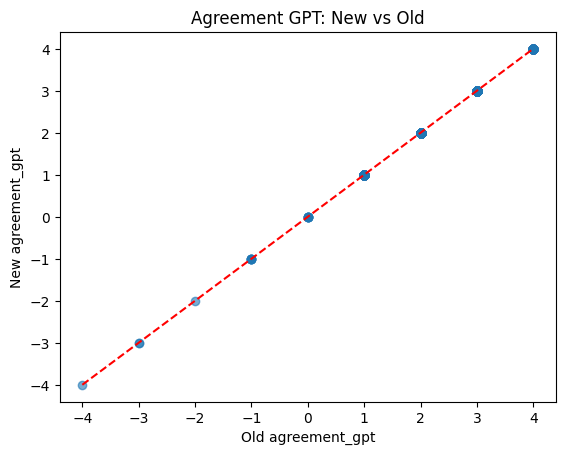

In [40]:

import matplotlib.pyplot as plt

plt.scatter(
    df_merged["Agreement_General_old"],
    df_merged["Agreement_General_new"],
    alpha=0.6
)

# 45-degree line for reference
min_val = min(df_merged["Agreement_General_old"].min(), df_merged["Agreement_General_new"].min())
max_val = max(df_merged["Agreement_General_old"].max(), df_merged["Agreement_General_new"].max())

plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")

plt.xlabel("Old agreement_gpt")
plt.ylabel("New agreement_gpt")
plt.title("Agreement GPT: New vs Old")

plt.show()


In [41]:
df_merged["Agreement_General_old"].corr(df_merged["Agreement_General_new"])

np.float64(1.0)

In [42]:

df_merged["diff"] = abs(df_merged["Agreement_General_new"] - df_merged["Agreement_General_old"])


df_merged[
    ["country", "year", "Agreement_General_old", "Agreement_General_new", "diff","Agreement_Monetary_old","Agreement_Monetary_new", "Agreement_Fiscal_old","Agreement_Fiscal_new","Agreement_Real_old","Agreement_Real_new"]
].sort_values("diff", ascending=False).head(50)



,country,year,Agreement_General_old,Agreement_General_new,diff,Agreement_Monetary_old,Agreement_Monetary_new,Agreement_Fiscal_old,Agreement_Fiscal_new,Agreement_Real_old,Agreement_Real_new
1017,Dominica,2024,2,2,0,NaN,NaN,3.0,3.0,3.0,3.0
0,Finland,2015,2,2,0,NaN,NaN,1.0,1.0,2.0,2.0
1,Spain,2015,1,1,0,NaN,NaN,2.0,2.0,2.0,2.0
2,Kingdom of the Netherlands - Aruba,2017,1,1,0,2.0,2.0,0.0,0.0,-1.0,-1.0
3,Republic of Moldova,2021,4,4,0,4.0,4.0,4.0,4.0,3.0,3.0
4,Trinidad and Tobago,2018,1,1,0,-1.0,-1.0,2.0,2.0,1.0,1.0
5,Republic of the Marshall Islands,2016,4,4,0,NaN,NaN,4.0,4.0,4.0,4.0
6,Romania,2021,3,3,0,2.0,2.0,3.0,3.0,2.0,2.0
7,Mongolia,2017,2,2,0,1.0,1.0,2.0,2.0,2.0,2.0
8,Colombia,2018,3,3,0,3.0,3.0,2.0,2.0,3.0,3.0


In [43]:

# New
print("New:", df_merged["Agreement_General_new"].corr(df_merged["sector_avg_new"]))

# Old
print("Old:",df_merged["Agreement_General_old"].corr(df_merged["sector_avg_old"]))


New: 0.8537553361582237
Old: 0.8405459499687289


Correlation between sectoral scores and aggregate score is similar across both versions. This is also shown in the charts below. 

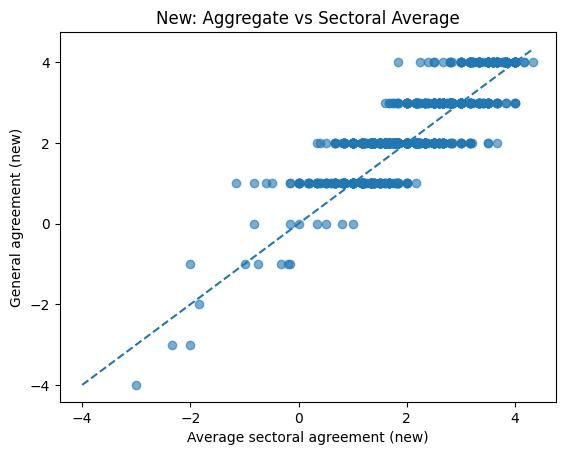

In [44]:

plt.scatter(
    df_merged["sector_avg_new"],
    df_merged["Agreement_General_new"],
    alpha=0.6
)

# 45-degree line
min_val = min(df_merged["sector_avg_new"].min(), df_merged["Agreement_General_new"].min())
max_val = max(df_merged["sector_avg_new"].max(), df_merged["Agreement_General_new"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Average sectoral agreement (new)")
plt.ylabel("General agreement (new)")
plt.title("New: Aggregate vs Sectoral Average")

plt.show()


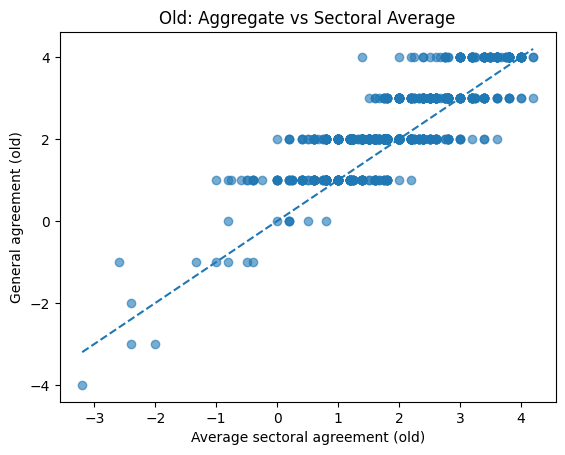

In [45]:

plt.scatter(
    df_merged["sector_avg_old"],
    df_merged["Agreement_General_old"],
    alpha=0.6
)

# 45-degree line
min_val = min(df_merged["sector_avg_old"].min(), df_merged["sector_avg_old"].min())
max_val = max(df_merged["sector_avg_old"].max(), df_merged["sector_avg_old"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Average sectoral agreement (old)")
plt.ylabel("General agreement (old)")
plt.title("Old: Aggregate vs Sectoral Average")

plt.show()

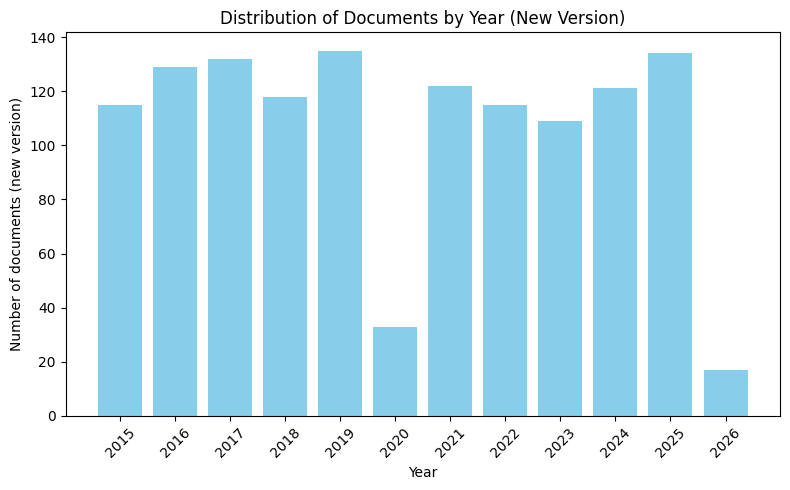

In [53]:
# Plot number of documents per year for the new version
doc_counts_new = df_new.groupby("year")["Agreement_General"].count().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(doc_counts_new.index, doc_counts_new.values, color="skyblue")
plt.xlabel("Year")
plt.ylabel("Number of documents (new version)")
plt.title("Distribution of Documents by Year (New Version)")
plt.xticks(doc_counts_new.index, rotation=45)
plt.tight_layout()
plt.show()

## Fixed-effects trends over time (New vs Old)

For each sector we run a two-way fixed-effects regression
`Agreement_<Sector> ~ C(year) + C(country)` with country-clustered SEs.

- **FE-adjusted** line = year effects holding the country composition fixed
  (Stata-style `margins`), so year-to-year moves are *not* driven by which
  countries happen to be in the sample that year.
- **Naive mean** = plain yearly average (affected by sample composition).

The gap between the two lines is the sample-composition bias. Each sector is
plotted as **New (v2)** vs **Old (v1)** side by side.

In [47]:
# -----------------------------------------------------------------------------
# Fixed-effects helpers (reused for every sector, New and Old)
# -----------------------------------------------------------------------------

YEAR_MIN, YEAR_MAX = 2015, 2025


def compute_fe_margins(df, sector_col, year_min=YEAR_MIN, year_max=YEAR_MAX):
    """Two-way FE regression + Stata-style margins for one Agreement_* column.

    Returns a per-year DataFrame with the FE-adjusted mean (+ 95% CI from
    country-clustered variation) and the naive yearly mean.
    """
    # Clean panel: need the outcome, year and country all present
    data = df.dropna(subset=[sector_col, "year", "country"]).copy()
    data["year"] = data["year"].astype(int)
    data = data[(data["year"] >= year_min) & (data["year"] <= year_max)]

    # 1. Two-way fixed-effects regression, country-clustered SEs
    model = smf.ols(
        f"{sector_col} ~ C(year) + C(country)",
        data=data,
    ).fit(cov_type="cluster", cov_kwds={"groups": data["country"]})

    # 2. Stata-equivalent margins: hold country composition fixed, vary year
    years = sorted(data["year"].unique())
    margins = []
    for y in years:
        temp = data.copy()
        temp["year"] = y
        margins.append({"year": y, "mean": model.predict(temp).mean()})
    df_margins = pd.DataFrame(margins)

    # 3. Clustered CI: collapse fitted values to country-year, vary across countries
    data["yhat"] = model.fittedvalues
    df_ci = (
        data.groupby(["year", "country"])["yhat"].mean().reset_index()
        .groupby("year").agg(std=("yhat", "std"), n=("yhat", "count")).reset_index()
    )
    df_margins = df_margins.merge(df_ci, on="year")
    df_margins["se"] = df_margins["std"] / np.sqrt(df_margins["n"])
    df_margins["lower"] = df_margins["mean"] - 1.96 * df_margins["se"]
    df_margins["upper"] = df_margins["mean"] + 1.96 * df_margins["se"]

    # 4. Naive mean (plain yearly average) for comparison
    df_naive = (
        data.groupby("year")[sector_col].mean().reset_index(name="mean_naive")
    )
    return df_margins.merge(df_naive, on="year")


def _plot_fe_panel(ax, df_plot, sector_col, title):
    """Draw one FE-vs-naive panel onto a given axis."""
    ax.plot(df_plot["year"], df_plot["mean"], marker="o", label="FE-adjusted")
    ax.fill_between(
        df_plot["year"], df_plot["lower"], df_plot["upper"],
        alpha=0.2, label="95% CI",
    )
    ax.plot(
        df_plot["year"], df_plot["mean_naive"],
        linestyle="--", color="grey", label="Naive mean",
    )
    ax.set_xlabel("Year")
    ax.set_ylabel(sector_col)
    ax.set_title(title)
    ax.legend()


def plot_fe_new_vs_old(sector_col, df_new_src=None, df_old_src=None):
    """Side-by-side FE-vs-naive plot: New on the left, Old on the right.
    Each panel gets its own independent y-axis (not shared).
    """
    df_new_src = df_new if df_new_src is None else df_new_src
    df_old_src = df_old if df_old_src is None else df_old_src

    plot_new = compute_fe_margins(df_new_src, sector_col)
    plot_old = compute_fe_margins(df_old_src, sector_col)

    # sharey=False -> each panel auto-scales its own y-axis independently
    fig, (ax_new, ax_old) = plt.subplots(
        1, 2, figsize=(13, 4.5), sharey=False,
    )
    _plot_fe_panel(
        ax_new, plot_new, sector_col,
        f"{sector_col} — New (with incremental update)",
    )
    _plot_fe_panel(
        ax_old, plot_old, sector_col,
        f"{sector_col} — Old (previous version with prompt change)",
    )
    fig.suptitle(f"{sector_col} over Time (FE vs Naive): New vs Old")
    fig.tight_layout()
    plt.show()
    return plot_new, plot_old

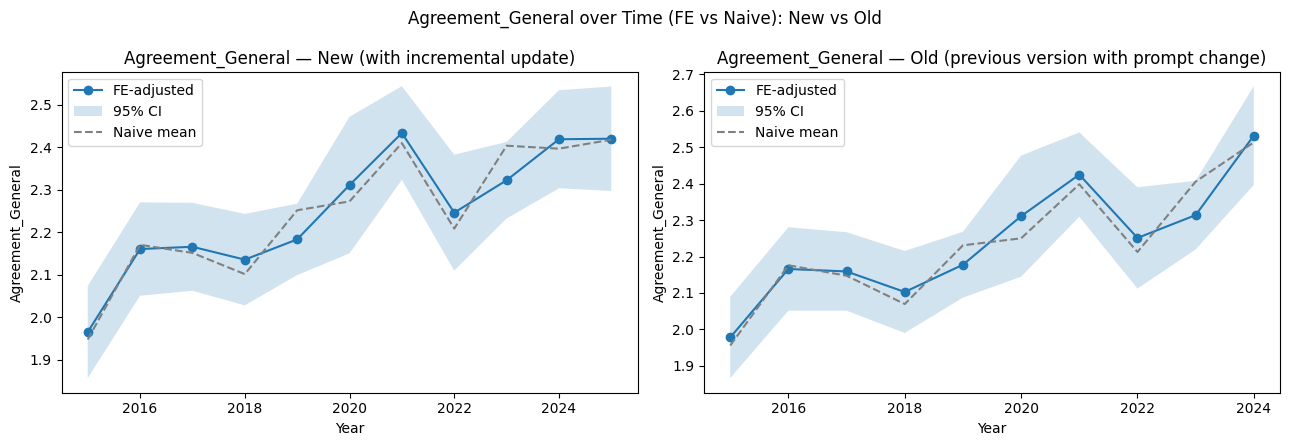

In [48]:
plot_fe_new_vs_old("Agreement_General");

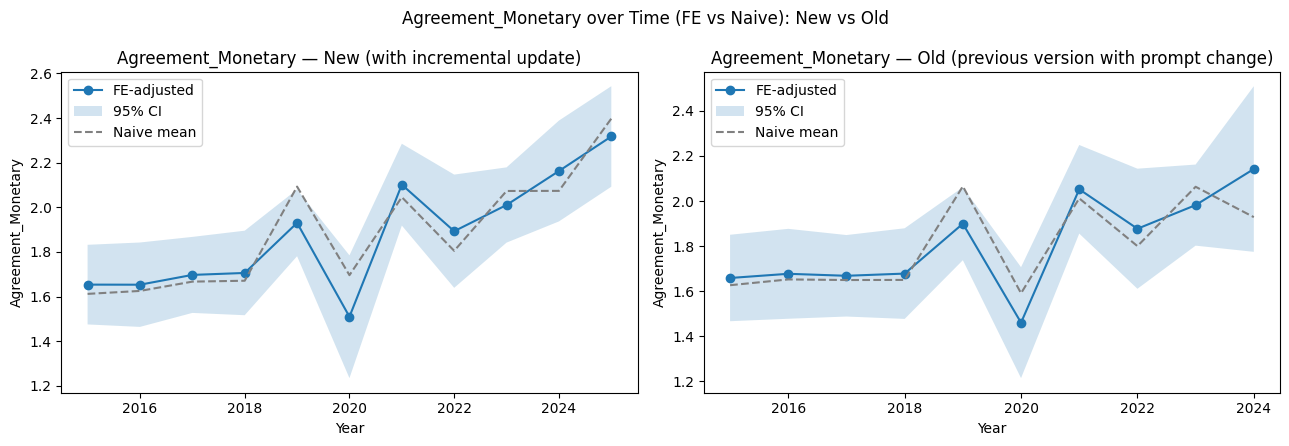

In [49]:
plot_fe_new_vs_old("Agreement_Monetary");

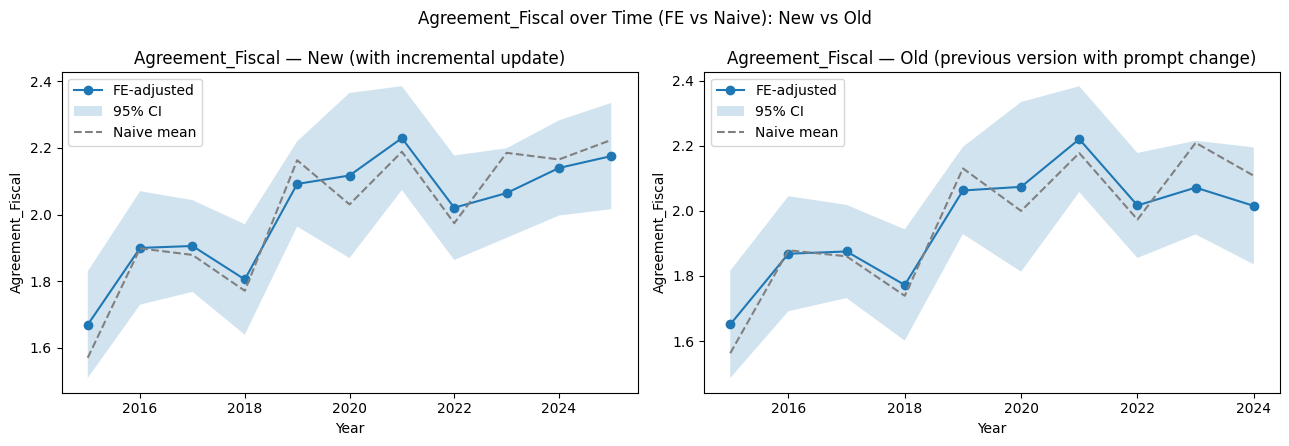

In [50]:
# NOTE: previously this cell dropped NA on Agreement_Monetary but regressed
# Agreement_Fiscal (copy-paste bug). The helper drops NA on the correct column.
plot_fe_new_vs_old("Agreement_Fiscal");

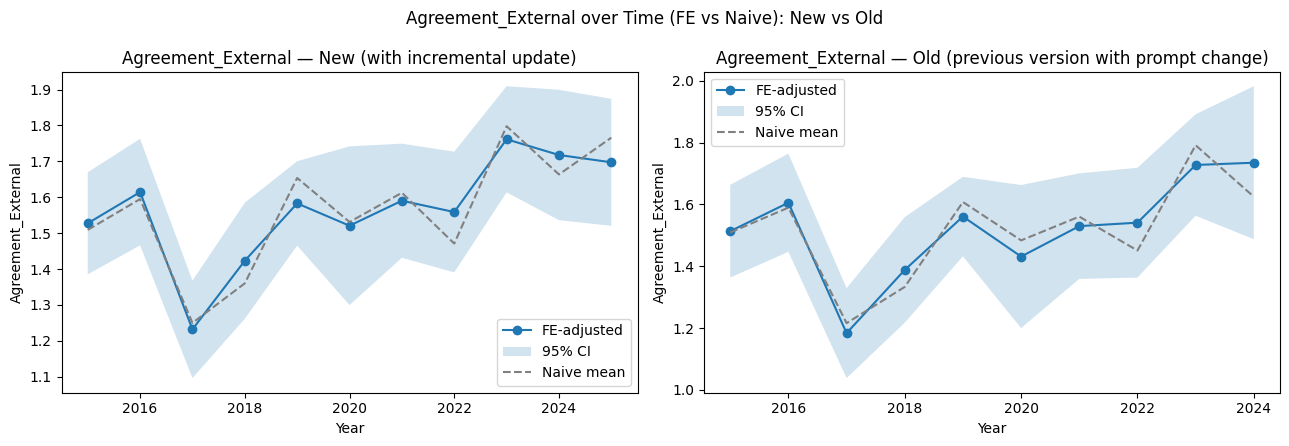

In [55]:
plot_fe_new_vs_old("Agreement_External");

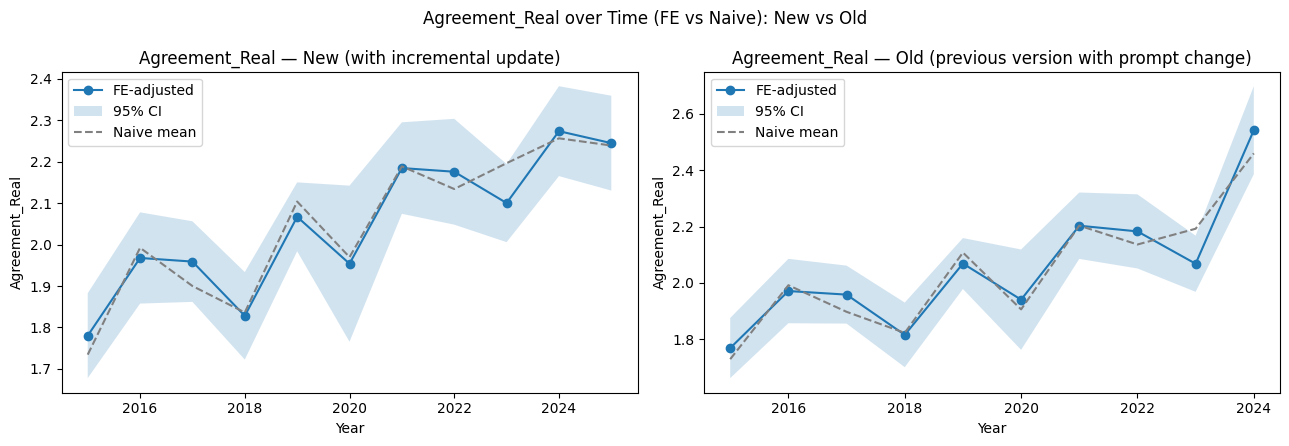

In [54]:
plot_fe_new_vs_old("Agreement_Real");